In [5]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json
import os
import glob
from matplotlib.ticker import FuncFormatter

# %load_ext autoreload
# %autoreload 2

# Import các thuật toán của bạn
import ex1_parametric
import ex2_over_conditioning
import ex3_data_splitting
import ex4_naive
import ex5_cort_without_inference
import ex6_bonferroni

In [7]:
# Đặt giới hạn số luồng xử lý cho mỗi thư viện tính toán về 1
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["MKL_NUM_THREADS"] = "4"
os.environ["OPENBLAS_NUM_THREADS"] = "4"
os.environ["VECLIB_MAXIMUM_THREADS"] = "4"
os.environ["NUMEXPR_NUM_THREADS"] = "4"

🚀 Bắt đầu chạy 5 thuật toán nhanh với h = [2, 6, 10, 14] (n_target=50)...

--- Processing h = 2 ---
Running Bonferroni
Iteration 0
Iteration 50
Iteration 100
Iteration 150
Iteration 200
Iteration 250
Iteration 300
Iteration 350
Iteration 400
Iteration 450
Iteration 500
Iteration 550
Iteration 600
Iteration 650
Iteration 700
Iteration 750
Iteration 800
Iteration 850
Iteration 900
Iteration 950
Done ------> (FPR: 0.000, TPR: 0.030)
Running DS
Iteration 0
Iteration 50
Iteration 100
Iteration 150
Iteration 200
Iteration 250
Iteration 300
Iteration 350
Iteration 400
Iteration 450
Iteration 500
Iteration 550
Iteration 600
Iteration 650
Iteration 700
Iteration 750
Iteration 800
Iteration 850
Iteration 900
Iteration 950
Done ------> (FPR: 0.050, TPR: 0.139)
Running Naive
Iteration 0
Iteration 50
Iteration 100
Iteration 150
Iteration 200
Iteration 250
Iteration 300
Iteration 350
Iteration 400
Iteration 450
Iteration 500
Iteration 550
Iteration 600
Iteration 650
Iteration 700
Iteration 750
Itera

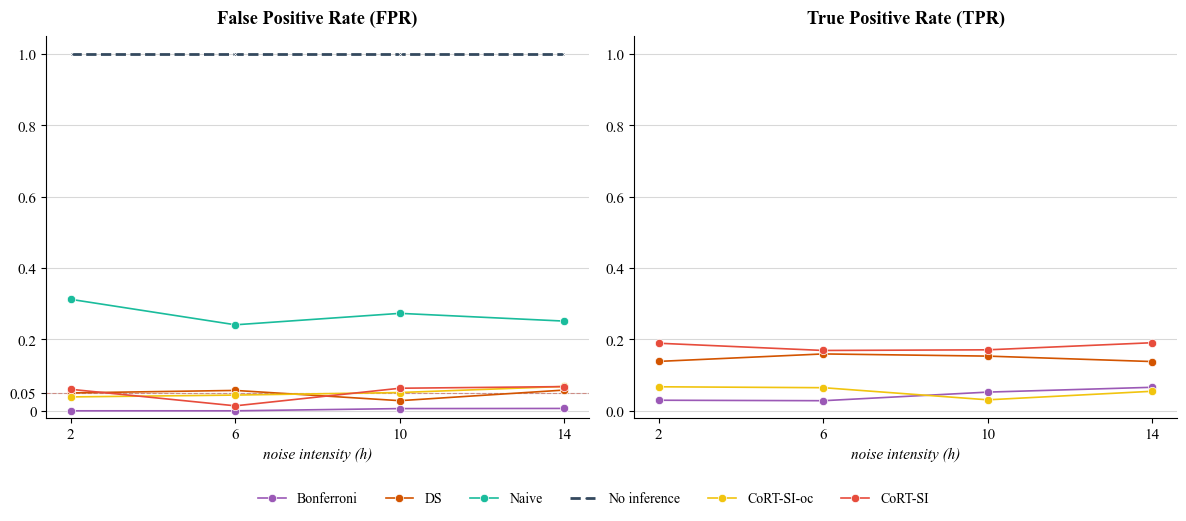

In [ ]:

# ==========================================
# PHẦN 1: CẤU HÌNH CHUNG
# ==========================================
iteration = 1000
n_source = 80
p = 200
K = 5
Ka = 2
alpha = 0.05
T = 5
s_len = 10
s_vector = [0.25] * s_len

# --- CẤU HÌNH MỚI CHO TRỤC HOÀNH LÀ h ---
# Cố định n_target
n_target = 50 

# Danh sách h cần chạy (Trục hoành)
# Dựa trên các file json bạn cung cấp: h = 2, 6, 10, 14
h_list = [2, 6, 10, 14]

# Định nghĩa các phương pháp
methods = {
    "Bonferroni":   {"func": ex6_bonferroni.bonferroni,               "color": "#9b59b6", "marker": "o", "ls": "-", "lw": 1.2, "zorder": 3},
    "DS":           {"func": ex3_data_splitting.data_splitting,       "color": "#d35400", "marker": "o", "ls": "-", "lw": 1.2, "zorder": 3},
    "Naive":        {"func": ex4_naive.naive,                         "color": "#1abc9c", "marker": "o", "ls": "-", "lw": 1.2, "zorder": 3},
    "No inference": {"func": ex5_cort_without_inference.cort_without_inference, "color": "#34495e", "marker": "x", "ls": "--","lw": 2.0, "zorder": 2},
    "CoRT-SI-oc":   {"func": ex2_over_conditioning.over_conditioning, "color": "#f1c40f", "marker": "o", "ls": "-", "lw": 1.2, "zorder": 3},
    "CoRT-SI":      {"func": None,                                    "color": "#e74c3c", "marker": "o", "ls": "-", "lw": 1.2, "zorder": 3}
}

experiment_results = {name: {"fpr": [], "tpr": []} for name in methods}

# ==========================================
# PHẦN 2: CHẠY 5 THUẬT TOÁN NHANH THEO h
# ==========================================
print(f"🚀 Bắt đầu chạy 5 thuật toán nhanh với h = {h_list} (n_target={n_target})...")

for h_val in h_list:
    print(f"\n--- Processing h = {h_val} ---")
    for name, config in methods.items():
        if name == "CoRT-SI":
            continue
            
        print(f"Running {name}")
        # Lưu ý: Truyền h_val vào vị trí tham số h, n_target cố định
        curr_fpr, curr_tpr = config["func"](
            iteration, n_target, n_source, p, K, Ka, h_val, alpha, T, s_len, s_vector
        )
        experiment_results[name]["fpr"].append(curr_fpr)
        experiment_results[name]["tpr"].append(curr_tpr)
        print(f"Done ------> (FPR: {curr_fpr:.3f}, TPR: {curr_tpr:.3f})")


# ==========================================
# PHẦN 3: LOAD KẾT QUẢ CoRT-SI TỪ THƯ MỤC records_3
# ==========================================
print("\n📂 Đang đọc dữ liệu CoRT-SI từ thư mục 'records_3/'...")

def load_cort_si_results_by_h(h_vals, fixed_n_target, fixed_n_source, fixed_p):
    folder_path = 'records_3/'  # <-- Đổi folder thành records_3
    
    # Kiểm tra thư mục
    if not os.path.exists(folder_path):
        print(f"❌ Thư mục '{folder_path}' không tồn tại. Vui lòng kiểm tra lại.")
        return [0]*len(h_vals), [0]*len(h_vals)

    file_pattern = os.path.join(folder_path, '*.json')
    list_files = glob.glob(file_pattern)
    
    if not list_files:
        print(f"❌ Không tìm thấy file JSON nào trong thư mục {folder_path}!")
        return [0]*len(h_vals), [0]*len(h_vals)

    all_dataframes = []
    for filename in list_files:
        try:
            with open(filename, 'r') as f:
                data = json.load(f)
                if data:
                    df = pd.json_normalize(data)
                    all_dataframes.append(df)
        except Exception as e:
            print(f"⚠️ Lỗi đọc file {filename}: {e}")

    if not all_dataframes:
        return [0]*len(h_vals), [0]*len(h_vals)

    big_df = pd.concat(all_dataframes, ignore_index=True)
    
    # --- BƯỚC LỌC DỮ LIỆU ---
    # Lọc theo các tham số CỐ ĐỊNH (n_target, n_source, p)
    original_len = len(big_df)
    
    # Kiểm tra cột tồn tại để tránh lỗi
    required_cols = ['configs.n_target', 'configs.n_source', 'configs.p', 'configs.h']
    if not all(col in big_df.columns for col in required_cols):
        print("❌ Dữ liệu JSON thiếu các cột cấu hình cần thiết.")
        return [0]*len(h_vals), [0]*len(h_vals)

    big_df = big_df[
        (big_df['configs.n_target'] == fixed_n_target) & 
        (big_df['configs.n_source'] == fixed_n_source) & 
        (big_df['configs.p'] == fixed_p)
    ]
    
    if big_df.empty:
        print(f"❌ Không còn dữ liệu sau khi lọc (n_target={fixed_n_target}, n_source={fixed_n_source}, p={fixed_p})!")
        return [0]*len(h_vals), [0]*len(h_vals)

    # Tính tổng hợp
    cols_to_sum = ['is_signal_cases', 'not_signal_cases', 'true_positives', 'false_positives']
    big_df[cols_to_sum] = big_df[cols_to_sum].fillna(0)
    
    # Group by configs.h (biến chạy)
    grouped = big_df.groupby('configs.h')[cols_to_sum].sum()
    
    # Hiển thị thống kê
    total_iters = grouped['is_signal_cases'] + grouped['not_signal_cases']
    print(f"   📊 Tổng số iterations tìm thấy cho mỗi h:\n{total_iters.to_string()}")

    # Tính TPR/FPR
    final_fprs = []
    final_tprs = []
    
    for h_val in h_vals:
        if h_val in grouped.index:
            row = grouped.loc[h_val]
            
            # FPR
            fpr = row['false_positives'] / row['not_signal_cases'] if row['not_signal_cases'] > 0 else 0.0
            # TPR
            tpr = row['true_positives'] / row['is_signal_cases'] if row['is_signal_cases'] > 0 else 0.0
                
            final_fprs.append(fpr)
            final_tprs.append(tpr)
        else:
            print(f"⚠️ Cảnh báo: Không có dữ liệu CoRT-SI cho h={h_val}. Gán bằng 0.")
            final_fprs.append(0.0)
            final_tprs.append(0.0)
            
    return final_fprs, final_tprs

# Gọi hàm xử lý với h_list và n_target cố định
cort_fpr, cort_tpr = load_cort_si_results_by_h(h_list, n_target, n_source, p)
experiment_results["CoRT-SI"]["fpr"] = cort_fpr
experiment_results["CoRT-SI"]["tpr"] = cort_tpr

print(f"✅ Đã nạp CoRT-SI hoàn tất: FPR={cort_fpr}, TPR={cort_tpr}")

# ==========================================
# PHẦN 4: VẼ BIỂU ĐỒ (VISUALIZATION)
# ==========================================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 11
plt.rcParams['axes.linewidth'] = 0.8

# --- SỬA LỖI Ở ĐÂY: Gán h_list cho x_axis_values ---
x_axis_values = h_list 
# ---------------------------------------------------

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

def format_func(value, tick_number):
    if abs(value - alpha) < 1e-9: return f'{alpha}'
    if value == 0.0: return '0'
    return f'{value:.1f}'

# === 1. BIỂU ĐỒ FPR ===
ax1.axhline(y=alpha, color='#e74c3c', linestyle='--', linewidth=0.8, alpha=0.6, zorder=1)

for name, data in experiment_results.items():
    cfg = methods[name]
    ax1.plot(x_axis_values, data["fpr"],  # Đã có biến x_axis_values
             label=name, 
             color=cfg["color"], 
             linestyle=cfg["ls"],
             marker=cfg["marker"], 
             markersize=6,      
             linewidth=cfg.get("lw", 1.2),     
             markeredgecolor='white', 
             markeredgewidth=0.5,
             zorder=cfg.get("zorder", 3)) 

# Tinh chỉnh trục FPR
standard_ticks = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
fpr_ticks = sorted(list(set(standard_ticks + [alpha])))
ax1.set_yticks(fpr_ticks)
ax1.yaxis.set_major_formatter(FuncFormatter(format_func))
ax1.set_title("False Positive Rate (FPR)", fontweight='bold', pad=10)
ax1.set_xlabel("noise intensity", style='italic') # Đặt tên trục cho rõ nghĩa
ax1.set_xticks(x_axis_values)
ax1.set_ylim(-0.02, 1.05)
ax1.grid(axis='y', linestyle='-', alpha=0.3, color='gray', zorder=0)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# === 2. BIỂU ĐỒ TPR ===
for name, data in experiment_results.items():
    if name in ["Naive", "No inference"]:
        continue
        
    cfg = methods[name]
    ax2.plot(x_axis_values, data["tpr"],  # Đã có biến x_axis_values
             label=name, 
             color=cfg["color"], 
             linestyle=cfg["ls"],
             marker=cfg["marker"],
             markersize=6,
             linewidth=cfg.get("lw", 1.2),
             markeredgecolor='white',
             markeredgewidth=0.5,
             zorder=cfg.get("zorder", 3))

# Tinh chỉnh trục TPR
ax2.set_title("True Positive Rate (TPR)", fontweight='bold', pad=10)
ax2.set_xlabel("noise intensity", style='italic') 
ax2.set_xticks(x_axis_values)
ax2.set_yticks(standard_ticks)
ax2.set_ylim(-0.02, 1.05)
ax2.grid(axis='y', linestyle='-', alpha=0.3, color='gray', zorder=0)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# --- LEGEND CHUNG ---
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, 
           loc='lower center', 
           bbox_to_anchor=(0.5, -0.05), 
           ncol=6, 
           frameon=False, 
           fontsize=10)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15) 
plt.show()